In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

In [2]:
close = pd.read_csv("../data/raw/close.csv", parse_dates=["Date"], index_col="Date")
log_price = np.log(close)
close.head()

,ADM,BG,CVX,GOLD,NEM,XLE,XOM,XOP
Date,,,,,,,,
2015-01-02,37.136803,65.808136,68.898323,3.532226,15.035707,25.365133,57.145542,156.158401
2015-01-05,35.851810,64.472610,66.144371,3.532226,15.128998,24.315826,55.581944,146.146149
2015-01-06,35.145046,63.866226,66.113754,3.404683,15.758725,23.958622,55.286453,141.721405
2015-01-07,35.673332,64.198311,66.058693,3.525141,15.618792,24.009645,55.846645,140.300354
2015-01-08,35.152191,65.374992,67.570305,3.450741,15.533269,24.548651,56.776199,145.048050


In [3]:
# candidate pairs, as defined in README.md
pairs = [
    ("XOM", "CVX"),
    ("XLE", "XOP"),
    ("NEM", "GOLD"),
    ("ADM", "BG"),
]

In [4]:
# hedge ratio via OLS on log prices: p_A = alpha + beta * p_B + spread
def compute_spread(a, b):
    y = log_price[a]
    x = sm.add_constant(log_price[b])
    model = sm.OLS(y, x).fit()
    alpha, beta = model.params["const"], model.params[b]
    spread = y - (alpha + beta * log_price[b])
    return spread, alpha, beta

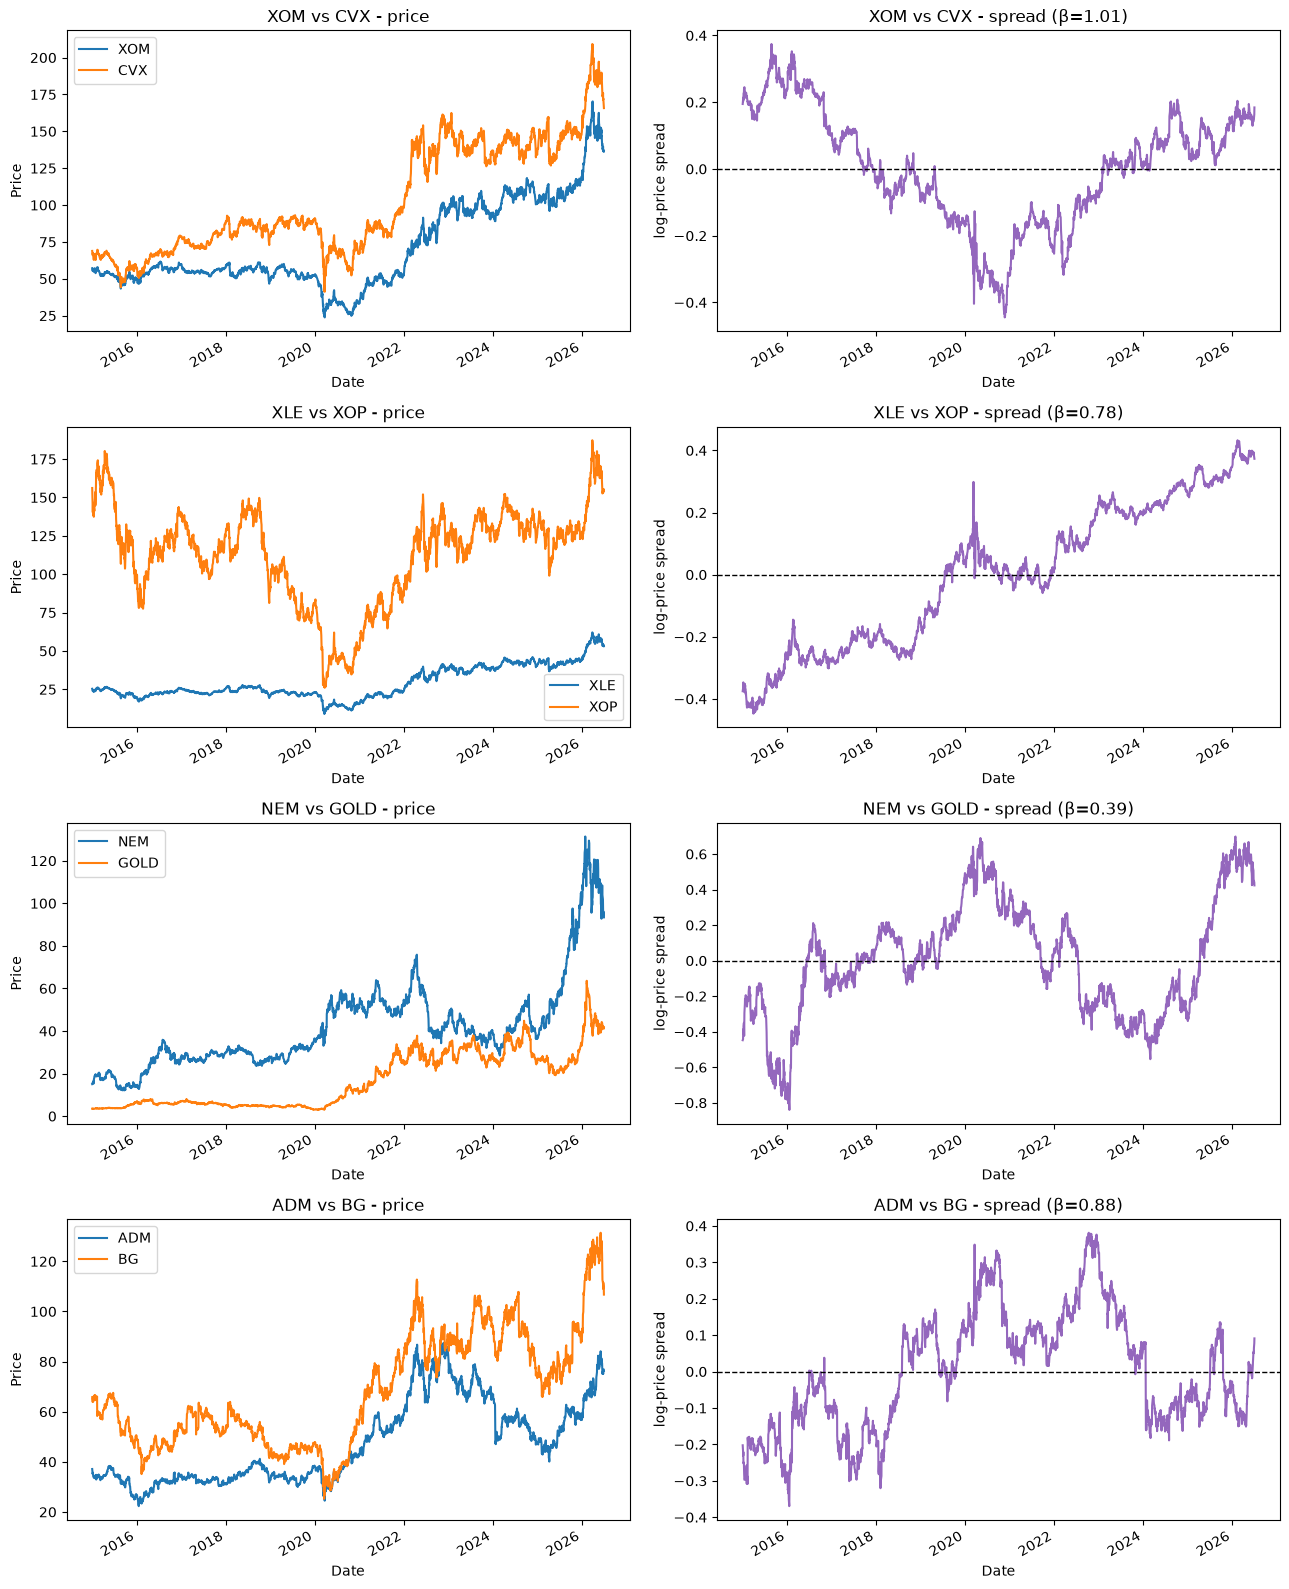

In [5]:
# time series plot of prices (left) and spread (right) for each pair
fig, axes = plt.subplots(len(pairs), 2, figsize=(13, 4 * len(pairs)))

for row, (a, b) in enumerate(pairs):
    spread, alpha, beta = compute_spread(a, b)

    ax_price = axes[row, 0]
    close[[a, b]].plot(ax=ax_price)
    ax_price.set_title(f"{a} vs {b} - price")
    ax_price.set_xlabel("Date")
    ax_price.set_ylabel("Price")

    ax_spread = axes[row, 1]
    spread.plot(ax=ax_spread, color="tab:purple")
    ax_spread.axhline(spread.mean(), color="black", linestyle="--", linewidth=1)
    ax_spread.set_title(f"{a} vs {b} - spread (\u03b2={beta:.2f})")
    ax_spread.set_xlabel("Date")
    ax_spread.set_ylabel("log-price spread")

fig.tight_layout()

From the spread, some of the pairs seem to oscillate around the average (XOM vs CVX, NEM vs GOLD, ADM vs BG) and XLE vs XOP seems to have a positive drift. The pair of XLE vs XOP also doesn't show any visible similarities in the price plot. This might indicate a lack cointegration. 

## Return distribution

In [6]:
from scipy import stats

returns = log_price.diff().dropna()
returns.head()

,ADM,BG,CVX,GOLD,NEM,XLE,XOM,XOP
Date,,,,,,,,
2015-01-05,-0.035214,-0.020503,-0.040792,0.000000,0.006185,-0.042248,-0.027743,-0.066264
2015-01-06,-0.019910,-0.009450,-0.000463,-0.036776,0.040781,-0.014799,-0.005330,-0.030744
2015-01-07,0.014920,0.005186,-0.000833,0.034769,-0.008919,0.002127,0.010082,-0.010078
2015-01-08,-0.014716,0.018163,0.022625,-0.021331,-0.005491,0.022201,0.016508,0.033280
2015-01-09,-0.008566,-0.012221,-0.020126,-0.003085,0.036368,-0.007957,-0.001410,0.007763


In [7]:
# skewness and (excess) kurtosis per security
dist_stats = pd.DataFrame({
    "skewness": returns.apply(stats.skew),
    "kurtosis (excess)": returns.apply(stats.kurtosis),
})
dist_stats

,skewness,kurtosis (excess)
ADM,-1.886998,26.748959
BG,-0.581479,11.713966
CVX,-0.954871,25.083645
GOLD,0.341789,6.985292
NEM,-0.312565,4.287184
XLE,-0.870649,15.582163
XOM,-0.200989,6.092173
XOP,-1.708652,37.022760


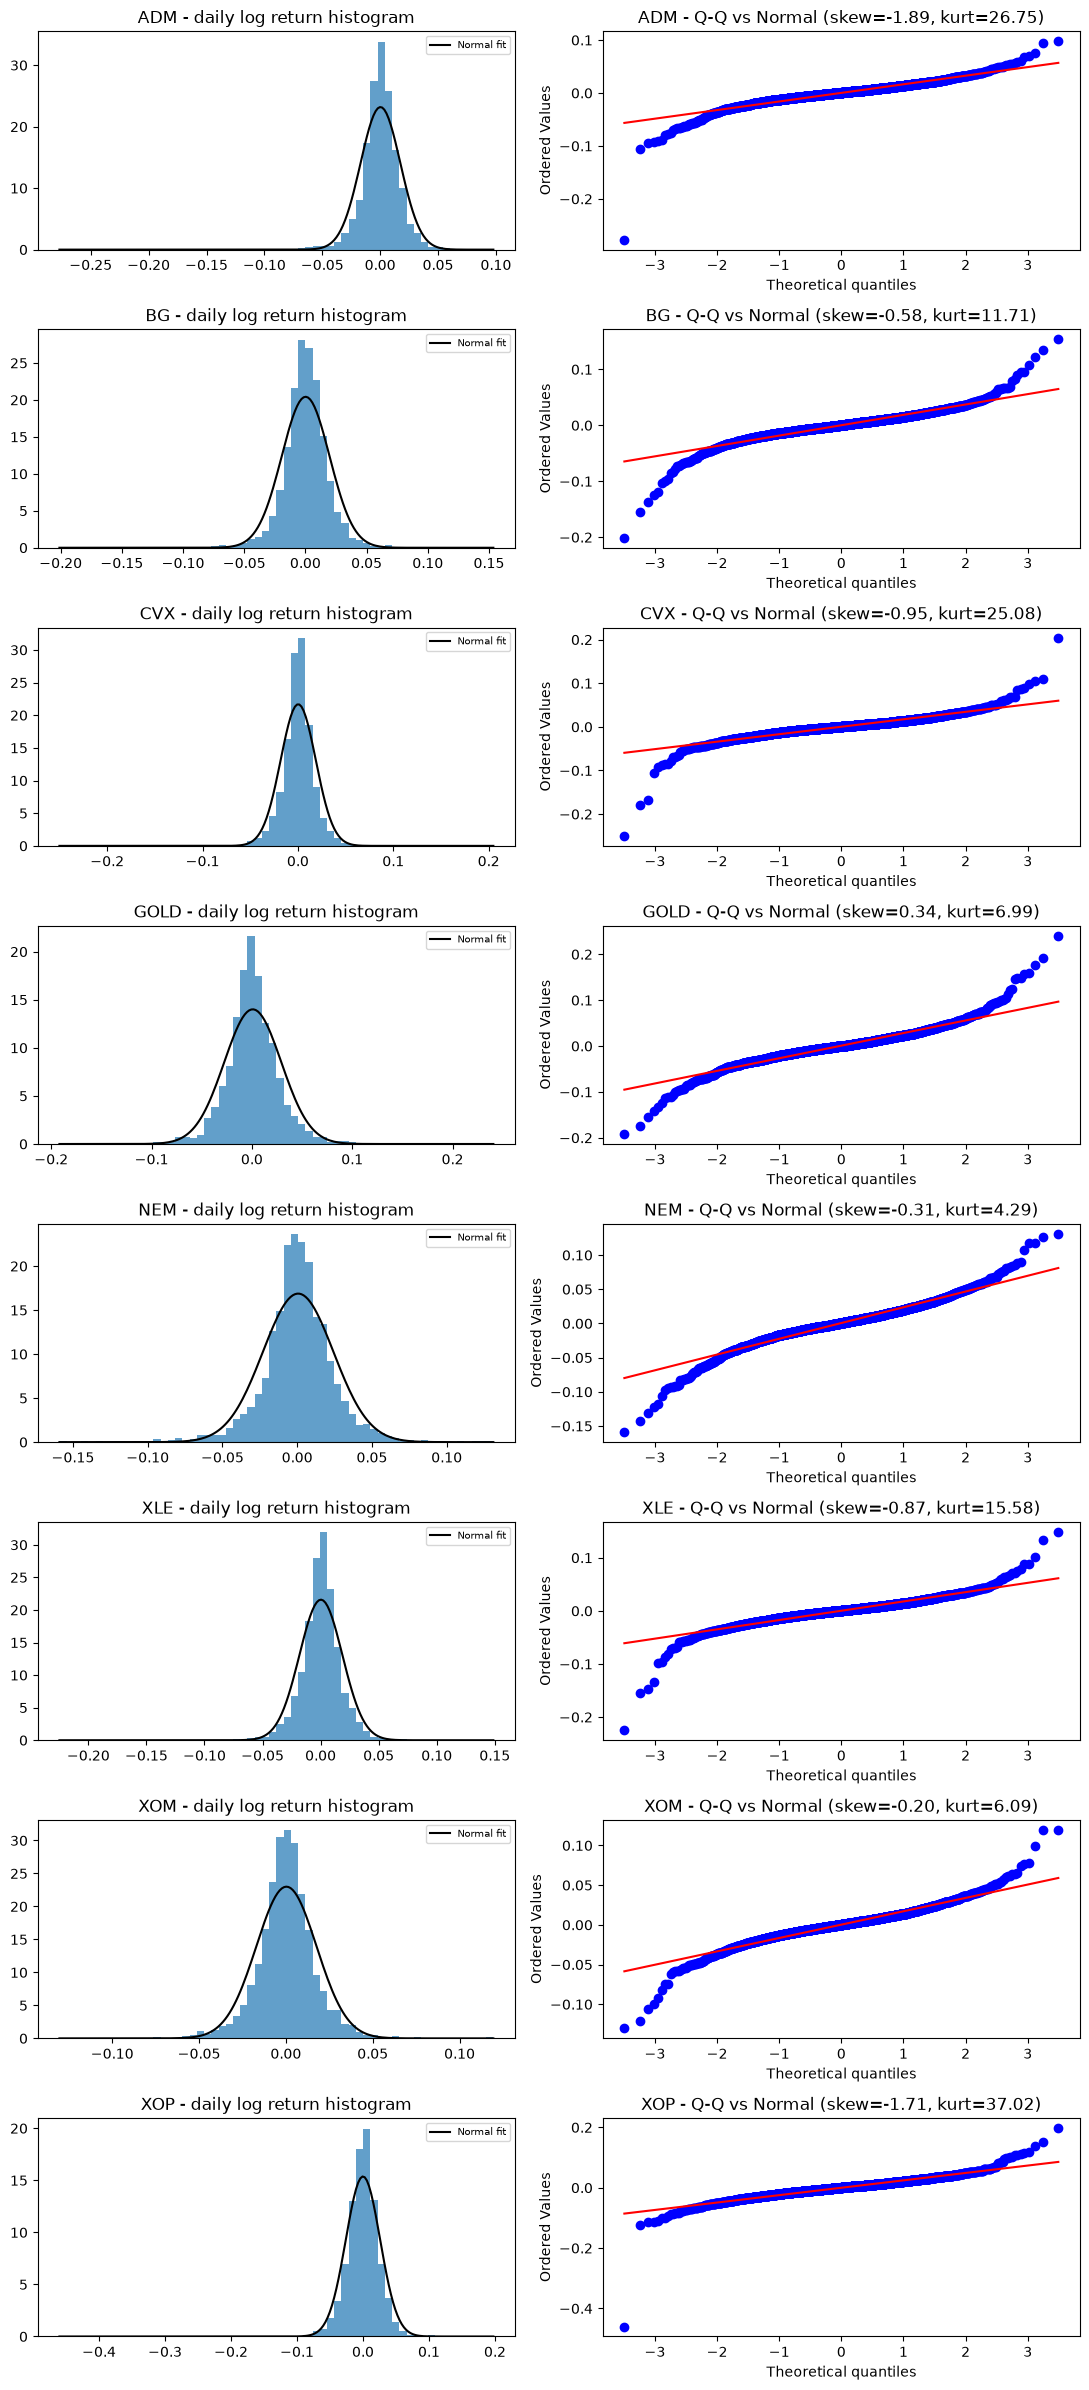

In [9]:
# histogram vs Normal fit (left) and Q-Q plot vs Normal (right) for each security's daily log returns
fig, axes = plt.subplots(len(returns.columns), 2, figsize=(11, 3 * len(returns.columns)))

for row, sec in enumerate(returns.columns):
    r = returns[sec]

    ax_hist = axes[row, 0]
    ax_hist.hist(r, bins=60, density=True, alpha=0.7)
    x = np.linspace(r.min(), r.max(), 200)
    ax_hist.plot(x, stats.norm.pdf(x, r.mean(), r.std()), color="black", linewidth=1.5, label="Normal fit")
    ax_hist.set_title(f"{sec} - daily log return histogram")
    ax_hist.legend(fontsize=7)

    ax_qq = axes[row, 1]
    stats.probplot(r, dist="norm", plot=ax_qq)
    skew = dist_stats.loc[sec, "skewness"]
    kurt = dist_stats.loc[sec, "kurtosis (excess)"]
    ax_qq.set_title(f"{sec} - Q-Q vs Normal (skew={skew:.2f}, kurt={kurt:.2f})")

fig.tight_layout()

The plots above allow for noticing several important factors.

Firstly ADM has a severe, isolated outlier visible on the Q-Q graph. This data should be further investigated to confirm its correctness. All of the series are non-normal, as the Q-Q plots are further from the red line at both tails. This indicates fat-tails which is expected for daily equity/commodity returns. All of the series except for GOLD have negative skew. 

AP:
- Check ADM outlier

In [ ]:
returns['ADM'].nsmallest(5)   # find the exact date of the outlier

Date
2024-01-22   -0.277034
2020-03-12   -0.106089
2025-04-04   -0.093588
2017-05-02   -0.092973
2016-02-02   -0.091482
Name: ADM, dtype: float64

The outlier is confirmed to be a correct measurement, a result of special events.